# Linear Regression, Polynomial Fit
changed from  https://jakevdp.github.io/PythonDataScienceHandbook/05.06-linear-regression.html 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

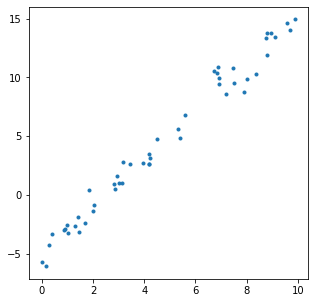

In [8]:
# create two numpy arrays of shape (50,)
rng = np.random.RandomState(seed=1)  # container for random number generators
x = 10 * rng.rand(50)                # 50 random numbers in [0,10] 
y = 2 * x - 5 + rng.randn(50)        # 50 numbers between [-5, 15] 
                                     # linear function of x plus some normal noise
# print(x)
# print(y)
# np.shape(x)
# np.shape(y)

%matplotlib inline
plt.rcParams["figure.figsize"] = (5, 5) # (width, height)
fig, ax = plt.subplots()
_ = ax.scatter(x,y, marker='.');
_ = plt.show();

In [9]:
# below we will use "newaxis" to increase the dimension of the array by one
# Here is an example of how it works
aa = np.array([1., 2.])
print("aa = ", aa)
bb = aa[:, np.newaxis]  # [[1.],[2.]]
print("bb = ", bb)

aa =  [1. 2.]
bb =  [[1.]
 [2.]]


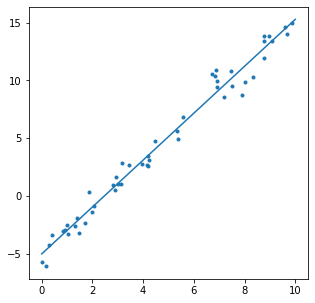

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)

# create numpy array of shape (1000,) with values in [0,10]
xt = np.linspace(0, 10, 1000)
# print(xt)
# print(type(xt))
# print(np.shape(xt))
yt = model.predict(xt[:, np.newaxis])
yp = model.predict(x[:, np.newaxis])
fig, ax = plt.subplots()
_ = ax.scatter(x,y, marker='.');
_ = ax.plot(xt, yt);
_ = plt.show();

In [12]:
# The coefficients
slope     = model.coef_[0]
intercept = model.intercept_
print("slope = %.3f, intercept = %.3f" % (slope,intercept))
print("Mean squared error : %.2f" % mean_squared_error(y,yp))
print('R2 Variance score  : %.2f' % r2_score(y, yp))

slope = 2.027, intercept = -4.999
Mean squared error : 0.82
R2 Variance score  : 0.98


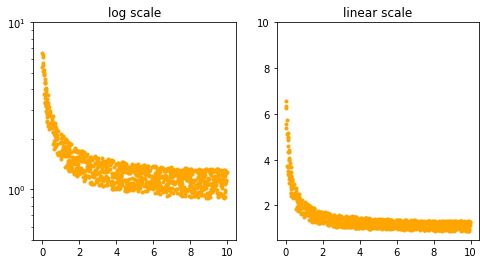

In [13]:
rng = np.random.RandomState(seed=1)
N=1000
x = 10 * rng.rand(N)
x = np.where(x<0.0001, 0.0001, x)
x2 = 0.4 * rng.rand(N) - 0.2
y = (1+1/(0.2+x))*(1+x2)

plt.rcParams["figure.figsize"] = (8, 4) # (width, height) 
fig,(ax1,ax2) = plt.subplots(1,2)
for ax in [ax1,ax2]:
    _ = ax.scatter(x,y, marker='.', color='orange')
    _ = ax.set_ylim(bottom=5e-1, top=10)
_ = ax1.set_yscale("log")
_ = ax2.set_yscale("linear")
_ = ax1.set_title("log scale")
_ = ax2.set_title("linear scale")
plt.show();

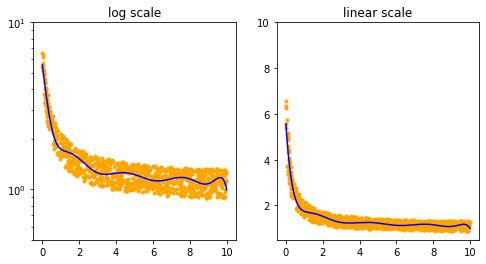

In [14]:
# polinomial fit
a  = np.array(x) # copy
b  = np.array(y) # copy

p9 = np.poly1d(np.polyfit(a,b,9))

xp = np.linspace(0,10,300)

plt.rcParams["figure.figsize"] = (8, 4) # (width, height) 
fig,(ax1,ax2) = plt.subplots(1,2)
for ax in [ax1,ax2]:
    _ = ax.scatter(x,y, marker='.', color='orange')
    _ = ax.plot(xp, p9(xp), color='blue')
    _ = ax.set_ylim(bottom=5e-1, top=10)
_ = ax1.set_yscale("log")
_ = ax2.set_yscale("linear")
_ = ax1.set_title("log scale")
_ = ax2.set_title("linear scale")
plt.show();